Total news articles: 51282
Total users: 50000
Total impressions: 156965


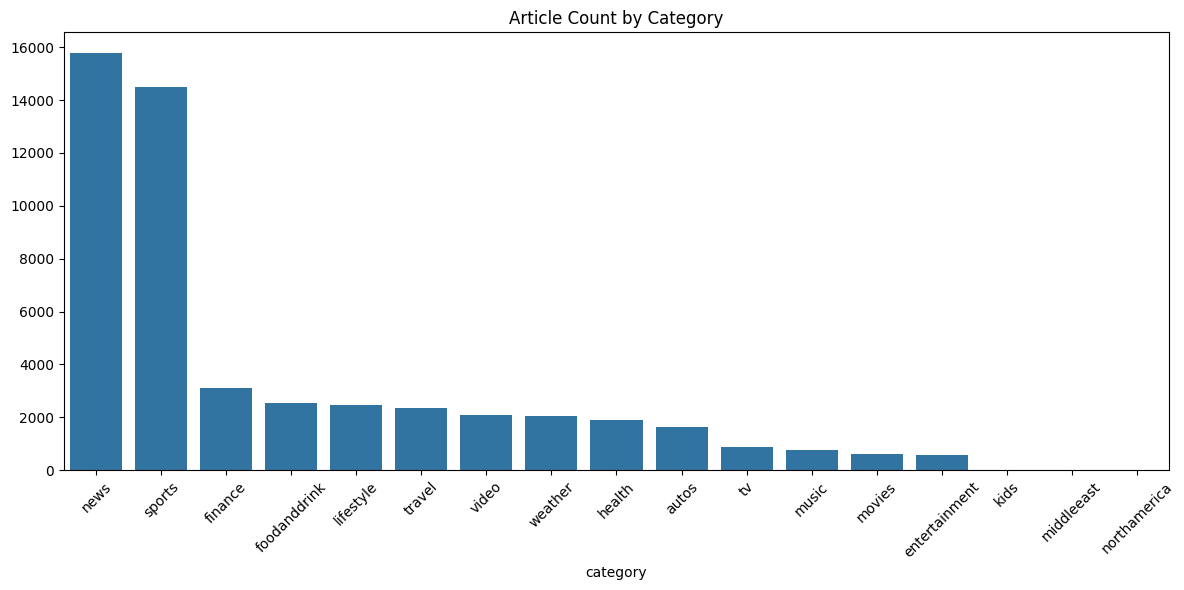

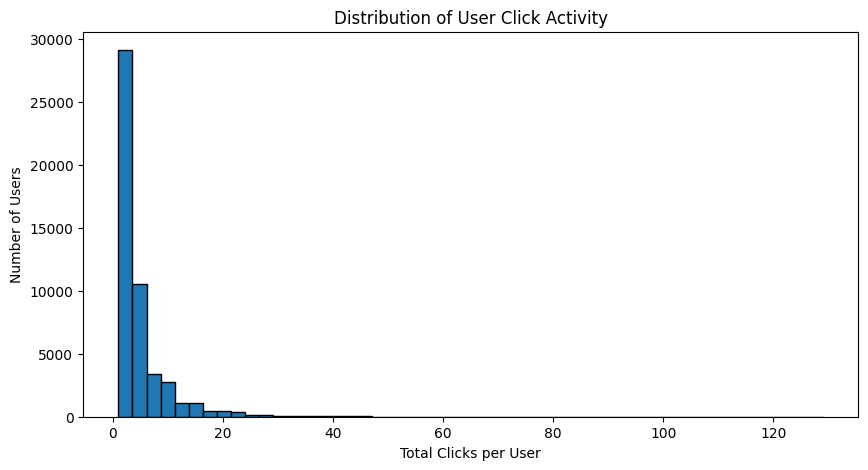

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load news data
news_cols = ['news_id', 'category', 'subcategory', 'title',
             'abstract', 'url', 'title_entities', 'abstract_entities']
news_df = pd.read_csv('data/MINDsmall_train/news.tsv',
                       sep='\t', names=news_cols)


# Load behaviors data
beh_cols = ['impression_id', 'user_id', 'time', 'history', 'impressions']
behaviors_df = pd.read_csv('data/MINDsmall_train/behaviors.tsv',
                            sep='\t', names=beh_cols)


# Basic statistics
print(f'Total news articles: {len(news_df)}')
print(f'Total users: {behaviors_df["user_id"].nunique()}')
print(f'Total impressions: {len(behaviors_df)}')

# Category distribution
cat_counts = news_df['category'].value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(x=cat_counts.index, y=cat_counts.values)
plt.title('Article Count by Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('results/category_distribution.png')


# User click distribution
def count_clicks(imp_str):
    if pd.isna(imp_str): return 0
    return sum(1 for x in imp_str.split() if x.endswith('-1'))


behaviors_df['n_clicks'] = behaviors_df['impressions'].apply(count_clicks)
user_clicks = behaviors_df.groupby('user_id')['n_clicks'].sum()
plt.figure(figsize=(10, 5))
plt.hist(user_clicks, bins=50, edgecolor='black')
plt.xlabel('Total Clicks per User')
plt.ylabel('Number of Users')
plt.title('Distribution of User Click Activity')
plt.savefig('results/user_click_dist.png')

In [60]:
id_category_dict = dict()

for index, row in news_df.iterrows():
    id_category_dict[news_df.loc[index, 'news_id']] = news_df.loc[index, 'category']

category_dict = dict()

for k,v in id_category_dict.items():
    category_dict[v] = 0

click_category_dict = category_dict.copy()

def impression_count(imp_str):
    count=0
    if pd.isna(imp_str): return 0
    for x in imp_str.split():
        count+=1
    return count

def count_clicks_per_category(imp_str):
    for row in imp_str:
        if pd.isna(row):
            continue
        for x in row.split():
            split_string = x.split('-')[0]
            cat = id_category_dict[split_string]
            category_dict[cat]+=1
            if x.endswith('-1'):
                click_category_dict[cat] += 1

count_clicks_per_category(behaviors_df['impressions'].values)

In [ ]:
#Question 13
click_count = user_clicks.sum()
total_count = (behaviors_df['impressions'].apply(impression_count)).sum()
print(f'Total Clicks: {click_count}')
print(f'Total Impressions: {total_count}')
print(f'Overall CTR: {click_count/total_count.sum()}')
for k,v in category_dict.items():
    val = click_category_dict[k]/category_dict[k] if click_category_dict[k]>0 else 0
    print(f'CTR for {k}: {val}')

#This shows that there is a very small amount of clicks compared to the number of 
#total impressions. We also see that categories like TV, weather, and music are the most
#popular categories in this dataset.

Total Clicks: 236344
Total Impressions: 5843444
Overall CTR: 0.040446010948338
CTR for lifestyle: 0.040559013792261685
CTR for health: 0.03572321170187577
CTR for news: 0.043624350895453155
CTR for sports: 0.04758487469310702
CTR for weather: 0.051688739480630824
CTR for entertainment: 0.030091732632240735
CTR for autos: 0.02736657505176365
CTR for travel: 0.026353454923976758
CTR for foodanddrink: 0.029462724225869156
CTR for tv: 0.05901112544733062
CTR for finance: 0.03647610732621296
CTR for movies: 0.03169027412919881
CTR for video: 0.045464243044888206
CTR for music: 0.059433176708499375
CTR for kids: 0.018518518518518517
CTR for middleeast: 0
CTR for northamerica: 0.034482758620689655


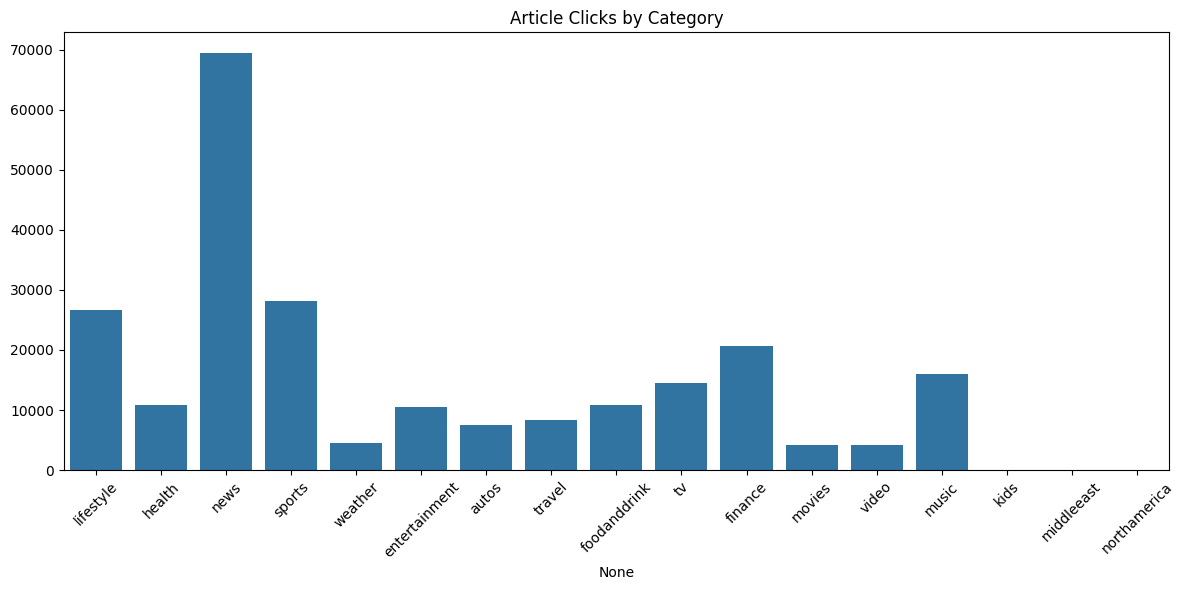

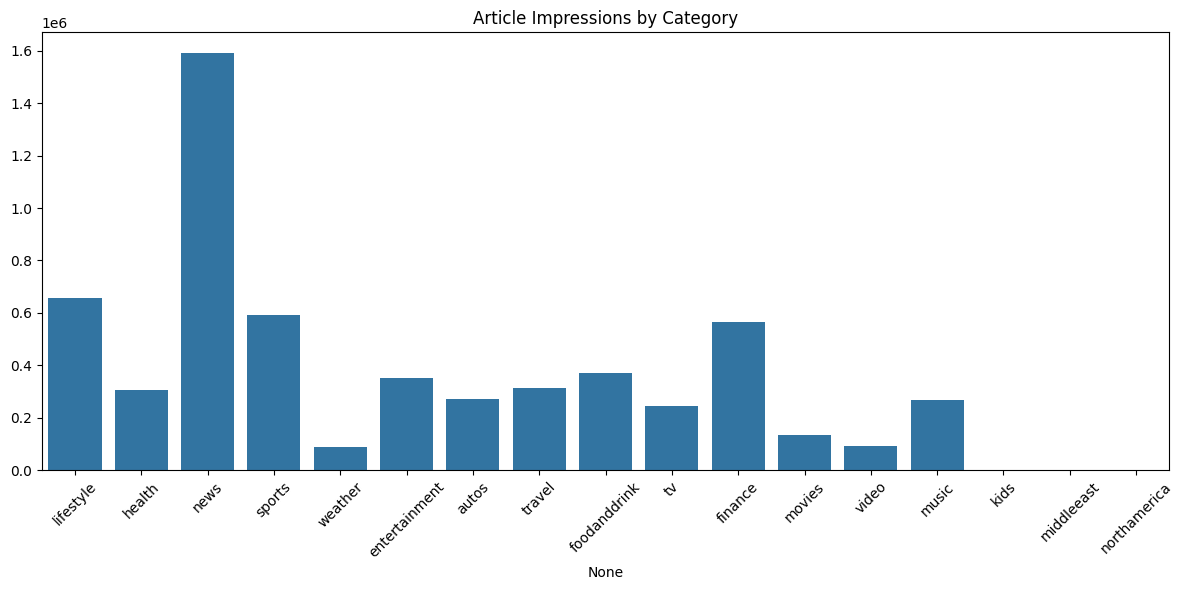

In [ ]:
#Question 14
category_clicks = pd.Series(click_category_dict)
plt.figure(figsize=(12, 6))
sns.barplot(x=category_clicks.index, y=category_clicks.values)
plt.title('Article Clicks by Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('results/category_click_distribution.png')

category_imp = pd.Series(category_dict)
plt.figure(figsize=(12, 6))
sns.barplot(x=category_imp.index, y=category_imp.values)
plt.title('Article Impressions by Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('results/category_impression_distribution.png')

#This shows, very clearly, that news is the most common category, while kids, north america,
#and middle east are very uncommon. This will come in handy for determining class weights
#later on.

In [ ]:
#Question 15
import numpy as np

total_users = 0
u_10_clicks = 0

for amount in user_clicks.values:
    total_users += 1
    if amount < 10:
        u_10_clicks += 1

print(f'Percentage of users with under 10 clicks: {u_10_clicks/total_users}')
print(f'Mean clicks: {np.mean(user_clicks.values)}')
print(f'Median clicks: {np.median(user_clicks.values)}')
print(f'90th percentile clicks: {np.percentile(user_clicks.values, 90)}')

#We see that an overwhelming majority of users have less than 10 clicks, with the average
#number of clicks being 4.7. This will be useful to keep in mind for predicting clicks and to
#not completely ignore the 90th percentile of clicks.

Percentage of users with under 10 clicks: 0.88328
Mean clicks: 4.72688
Median clicks: 3.0
90th percentile clicks: 10.0


In [ ]:
#Question 17
print(f'Average amount of candidates per impression: {total_count/len(behaviors_df)}')
print(f'Average click rate: {click_count/total_count.sum()}')

#Every user has a lot of impressions, 37, compared to just a 4% click rate. This shows us
#that it is hard to get user interaction.

Average amount of candidates per impression: 37.22768770107986
Average click rate: 0.040446010948338


In [102]:
time_imp_df = behaviors_df[['time','impressions']]
day_imp_dict = dict()
time_imp_dict = dict()

for i in range(len(time_imp_df.values)):
    count = count_clicks(time_imp_df['impressions'].values[i])
    day = time_imp_df['time'].values[i].split()[0]
    time = " ".join(time_imp_df['time'].values[i].split()[1:])

    if day in day_imp_dict:
        day_imp_dict[day] += count
    else:
        day_imp_dict[day] = count
    
    if time in time_imp_dict:
        time_imp_dict[time] += count
    else:
        time_imp_dict[time] = count

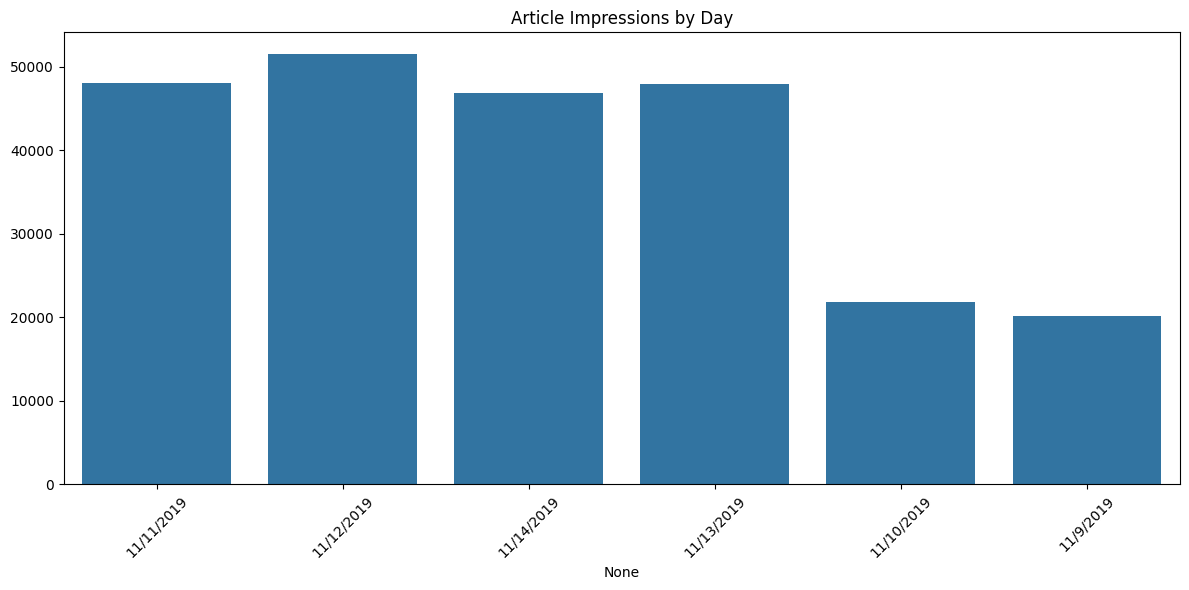

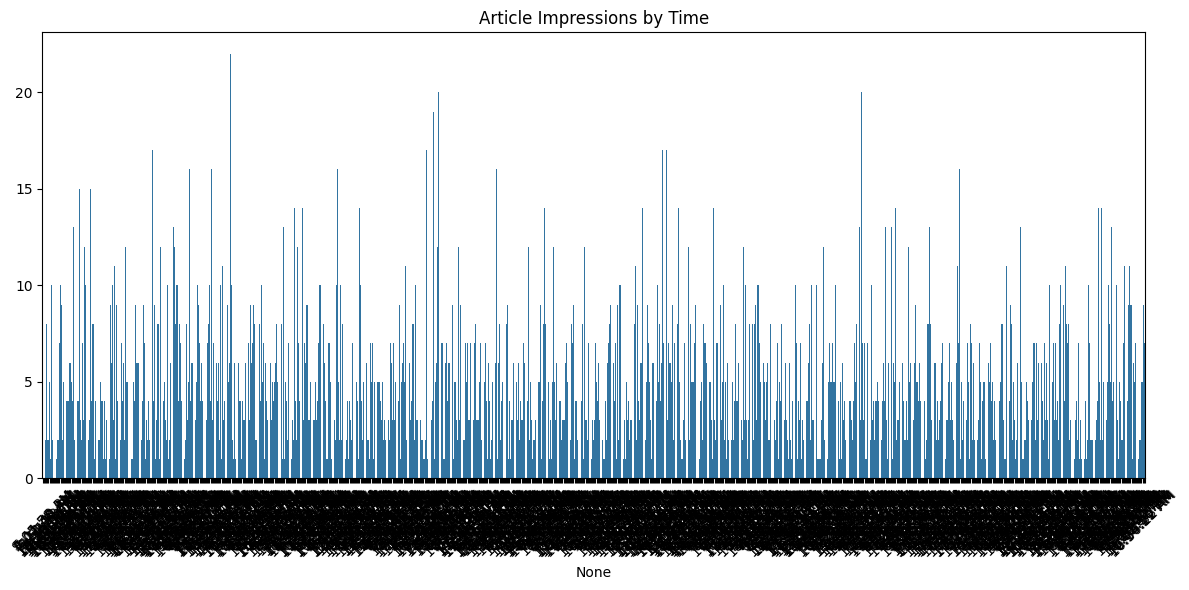

In [ ]:
#Question 18
day_imps = pd.Series(day_imp_dict)
plt.figure(figsize=(12, 6))
sns.barplot(x=day_imps.index, y=day_imps.values)
plt.title('Article Impressions by Day')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('results/day_imp_distribution.png')

time_imps = pd.Series(time_imp_dict)[0:1000]
plt.figure(figsize=(12, 6))
sns.barplot(x=time_imps.index, y=time_imps.values)
plt.title('Article Impressions by Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('results/Time_imp_distribution.png')

#These graphs show that the first 4 days have more impressions than the last two. Also,
#from the first 1000 times, there does not seem to be a relationship between time and
#popularity of interacting with news